In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from mesa.batchrunner import batch_run
from model import InformationModel, INFO_LEVELS

### Batch 1 — Vary Cognitive Capacity
Signal noise and task complexity held at 0.0. Cognitive capacity varied from 2 to 14.
The first 20 steps are discarded as burn-in to allow the exponential smoothing in each
agent to converge before means are calculated.

In [3]:
results1 = batch_run(
    InformationModel,
    parameters={
        'cognitive_capacity': list(range(2, 16, 2)),
        'signal_noise':       [0.0],
        'task_complexity':    [0.0],
    },
    rng=[None] * 5,
    max_steps=100,
    data_collection_period=1,
    display_progress=True,
)
df1 = pd.DataFrame(results1)
df1 = df1[df1['Step'] > 20]
df1.to_csv('batch_capacity.csv', index=False)

  0%|          | 0/35 [00:00<?, ?it/s]

In [4]:
# Table 1 — mean quality per capacity x load combination
load_cols = [str(l) for l in INFO_LEVELS]
cap_means = df1.groupby('cognitive_capacity')[load_cols].mean()
print('Table 1 — Mean Decision Quality by Cognitive Capacity and Info Load')
cap_means.round(2)

Table 1 — Mean Decision Quality by Cognitive Capacity and Info Load


,1,3,5,8,12,18
cognitive_capacity,,,,,,
2,0.39,0.63,0.63,0.59,0.56,0.54
4,0.22,0.53,0.63,0.62,0.58,0.55
6,0.15,0.39,0.57,0.63,0.60,0.56
8,0.12,0.31,0.46,0.63,0.61,0.56
10,0.10,0.26,0.39,0.55,0.63,0.57
12,0.08,0.22,0.34,0.49,0.63,0.59
14,0.07,0.19,0.30,0.44,0.58,0.62


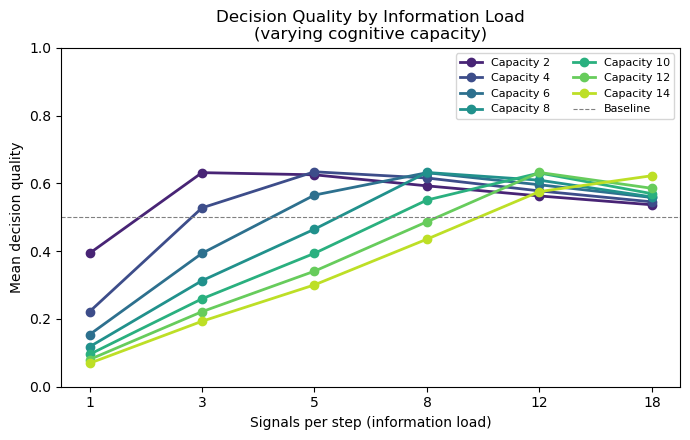

In [18]:
# Figure 1 — Line chart: quality vs load
# Each line is one cognitive capacity condition.
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = cm.viridis(np.linspace(0.1, 0.9, len(cap_means)))
for (cap, row), col in zip(cap_means.iterrows(), colors):
    ax.plot(load_cols, row.values,
            marker='o', label=f'Capacity {int(cap)}', color=col, linewidth=2)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Baseline')
ax.set_title('Decision Quality by Information Load\n(varying cognitive capacity)')
ax.set_xlabel('Signals per step (information load)')
ax.set_ylabel('Mean decision quality')
ax.set_ylim(0, 1)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('figure1.png', dpi=150, bbox_inches='tight')
plt.show()

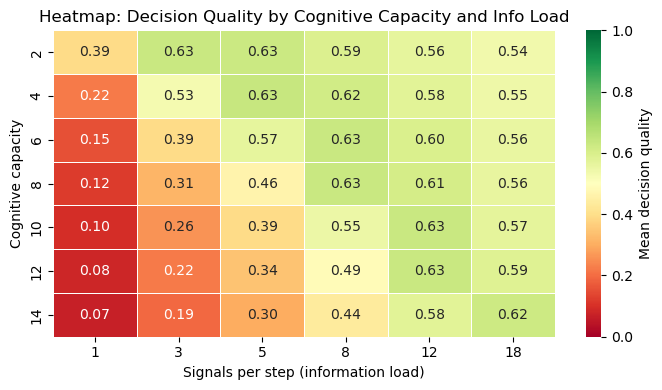

In [19]:
# Figure 2 — Heatmap: capacity x load
# The diagonal pattern of peak quality values confirms that what counts as an optimal information environment depends entirely on agent capacity.
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    cap_means.astype(float),
    annot=True, fmt='.2f',
    cmap='RdYlGn', vmin=0, vmax=1,
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Mean decision quality'}
)
ax.set_title('Heatmap: Decision Quality by Cognitive Capacity and Info Load')
ax.set_xlabel('Signals per step (information load)')
ax.set_ylabel('Cognitive capacity')
plt.tight_layout()
plt.savefig('figure2.png', dpi=150, bbox_inches='tight')
plt.show()

### Batch 2 — Vary Signal Noise
Cognitive capacity fixed at 6. Task complexity held at 0. Signal noise varied at 0.0,
0.25, and 0.5. Signal noise represents how unreliable or corrupted incoming information
is

In [7]:
results2 = batch_run(
    InformationModel,
    parameters={
        'cognitive_capacity': [6],
        'signal_noise':       [0.0, 0.25, 0.5],
        'task_complexity':    [0.0],
    },
    rng=[None] * 5,
    max_steps=100,
    data_collection_period=1,
    display_progress=True,
)
df2 = pd.DataFrame(results2)
df2 = df2[df2['Step'] > 20]
df2.to_csv('batch_noise.csv', index=False)

  0%|          | 0/15 [00:00<?, ?it/s]

In [8]:
# Table 2 — mean quality per noise level x load
noise_means = df2.groupby('signal_noise')[load_cols].mean()
print('Table 2 — Mean Decision Quality by Signal Noise and Info Load (capacity = 6)')
noise_means.round(2)

Table 2 — Mean Decision Quality by Signal Noise and Info Load (capacity = 6)


,1,3,5,8,12,18
signal_noise,,,,,,
0.00,0.15,0.39,0.57,0.63,0.59,0.54
0.25,0.15,0.39,0.57,0.61,0.57,0.55
0.50,0.16,0.40,0.56,0.58,0.53,0.53


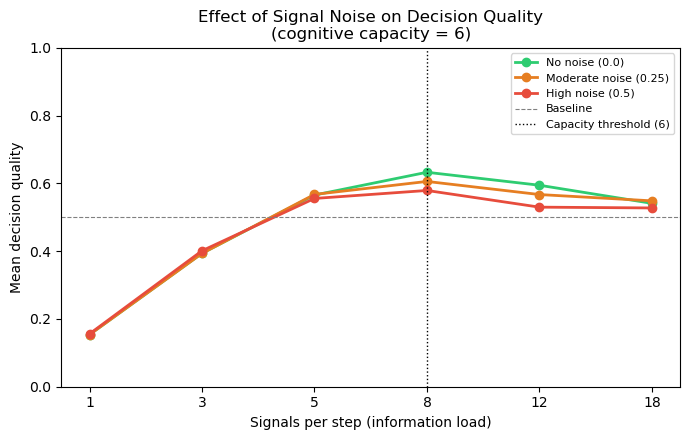

In [21]:
# Figure 3 — Line chart: quality vs load at three noise levels
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ['#2ecc71', '#e67e22', '#e74c3c']
labels = ['No noise (0.0)', 'Moderate noise (0.25)', 'High noise (0.5)']
for (noise, row), col, lbl in zip(noise_means.iterrows(), colors, labels):
    ax.plot(load_cols, row.values,
            marker='o', label=lbl, color=col, linewidth=2)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Baseline')
ax.axvline(load_cols.index('8'), color='black', linestyle=':', linewidth=1,
           label='Capacity threshold (6)')
ax.set_title('Effect of Signal Noise on Decision Quality\n(cognitive capacity = 6)')
ax.set_xlabel('Signals per step (information load)')
ax.set_ylabel('Mean decision quality')
ax.set_ylim(0, 1)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('figure3.png', dpi=150, bbox_inches='tight')
plt.show()

### Batch 3 — Vary Task Complexity
Cognitive capacity fixed at 6. Signal noise held at 0.0. Task complexity varied at 0.0,
0.5, and 0.9. Task complexity here represents how cognitively demanding the decision
itself is.

In [10]:
results3 = batch_run(
    InformationModel,
    parameters={
        'cognitive_capacity': [6],
        'signal_noise':       [0.0],
        'task_complexity':    [0.0, 0.5, 0.9],
    },
    rng=[None] * 5,
    max_steps=100,
    data_collection_period=1,
    display_progress=True,
)
df3 = pd.DataFrame(results3)
df3 = df3[df3['Step'] > 20]
df3.to_csv('batch_complexity.csv', index=False)

  0%|          | 0/15 [00:00<?, ?it/s]

In [11]:
# Table 3 — mean quality per complexity level x load
complexity_means = df3.groupby('task_complexity')[load_cols].mean()
print('Table 3 — Mean Decision Quality by Task Complexity and Info Load (capacity = 6)')
complexity_means.round(2)

Table 3 — Mean Decision Quality by Task Complexity and Info Load (capacity = 6)


,1,3,5,8,12,18
task_complexity,,,,,,
0.0,0.15,0.39,0.57,0.63,0.59,0.55
0.5,0.11,0.28,0.43,0.49,0.50,0.50
0.9,0.08,0.23,0.36,0.41,0.44,0.47


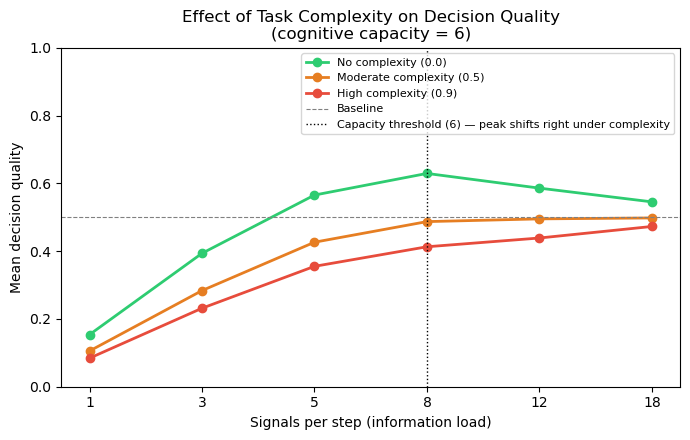

In [22]:
# Figure 4 — Line chart: quality vs load at three complexity levels
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ['#2ecc71', '#e67e22', '#e74c3c']
labels = ['No complexity (0.0)', 'Moderate complexity (0.5)', 'High complexity (0.9)']
for (comp, row), col, lbl in zip(complexity_means.iterrows(), colors, labels):
    ax.plot(load_cols, row.values,
            marker='o', label=lbl, color=col, linewidth=2)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Baseline')
ax.axvline(load_cols.index('8'), color='black', linestyle=':', linewidth=1,
           label='Capacity threshold (6) — peak shifts right under complexity')
ax.set_title('Effect of Task Complexity on Decision Quality\n(cognitive capacity = 6)')
ax.set_xlabel('Signals per step (information load)')
ax.set_ylabel('Mean decision quality')
ax.set_ylim(0, 1)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('figure4.png', dpi=150, bbox_inches='tight')
plt.show()

### Batch 4 — Three-Stressor Interaction
Cognitive capacity fixed at 6. All three stressors active simultaneously: signal noise
at 0.25 (moderate) and task complexity at 0.5 (moderate), compared against the clean
baseline (noise = 0, complexity = 0).

In [13]:
results4 = batch_run(
    InformationModel,
    parameters={
        'cognitive_capacity': [6],
        'signal_noise':       [0.0,  0.25, 0.5],
        'task_complexity':    [0.0,  0.5,  0.9],
    },
    rng=[None] * 5,
    max_steps=100,
    data_collection_period=1,
    display_progress=True,
)
df4 = pd.DataFrame(results4)
df4 = df4[df4['Step'] > 20]   # drop Steps 0-20 as smoothing warm-up
df4.to_csv('batch_interaction.csv', index=False)

  0%|          | 0/45 [00:00<?, ?it/s]

In [14]:
# Compute mean quality per (noise, complexity) combination across all info loads
interaction_means = df4.groupby(['signal_noise', 'task_complexity'])[load_cols].mean()
print('Table 4 — Mean Decision Quality by Noise x Complexity Combination (capacity = 6)')
interaction_means.round(2)

Table 4 — Mean Decision Quality by Noise x Complexity Combination (capacity = 6)


1     3     5     8    12    18
signal_noise task_complexity                                    
0.00         0.0              0.15  0.39  0.57  0.63  0.59  0.54
             0.5              0.11  0.28  0.43  0.48  0.49  0.49
             0.9              0.08  0.23  0.36  0.41  0.43  0.48
0.25         0.0              0.15  0.39  0.56  0.60  0.58  0.54
             0.5              0.11  0.29  0.42  0.49  0.51  0.49
             0.9              0.08  0.24  0.35  0.43  0.45  0.47
0.50         0.0              0.15  0.40  0.55  0.56  0.56  0.52
             0.5              0.11  0.30  0.45  0.50  0.49  0.51
             0.9              0.09  0.26  0.39  0.44  0.48  0.49

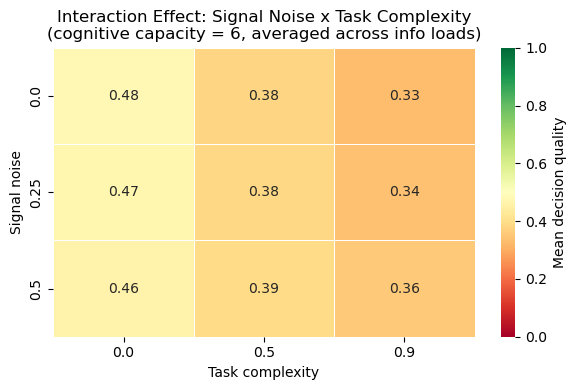

In [15]:
# Figure 5 — Heatmap: mean quality across noise x complexity conditions
# Each cell shows quality averaged across all six info-load groups
pivot = interaction_means.mean(axis=1).unstack(level='task_complexity')
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    pivot.astype(float),
    annot=True, fmt='.2f',
    cmap='RdYlGn', vmin=0, vmax=1,
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Mean decision quality'}
)
ax.set_title('Interaction Effect: Signal Noise x Task Complexity\n(cognitive capacity = 6, averaged across info loads)')
ax.set_xlabel('Task complexity')
ax.set_ylabel('Signal noise')
plt.tight_layout()
plt.show()

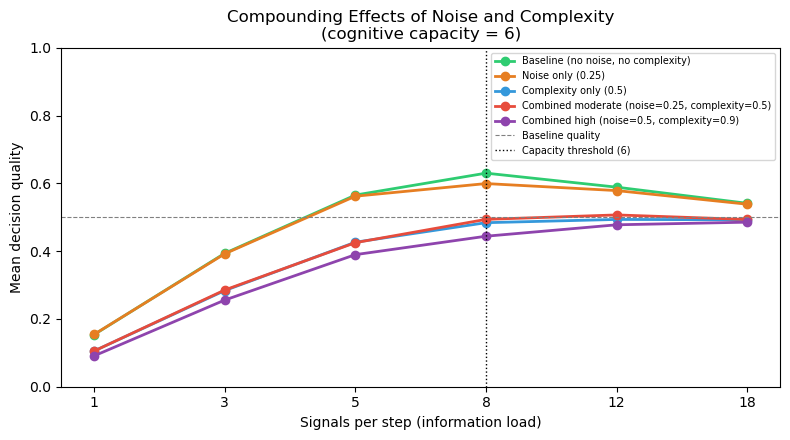

In [16]:
# Figure 6 — Line chart: three selected conditions across info loads
conditions = [
    (0.0,  0.0,  '#2ecc71', 'Baseline (no noise, no complexity)'),
    (0.25, 0.0,  '#e67e22', 'Noise only (0.25)'),
    (0.0,  0.5,  '#3498db', 'Complexity only (0.5)'),
    (0.25, 0.5,  '#e74c3c', 'Combined moderate (noise=0.25, complexity=0.5)'),
    (0.5,  0.9,  '#8e44ad', 'Combined high (noise=0.5, complexity=0.9)'),
]
fig, ax = plt.subplots(figsize=(8, 4.5))
for noise, comp, col, lbl in conditions:
    subset = df4[(df4['signal_noise'] == noise) & (df4['task_complexity'] == comp)]
    if subset.empty:
        continue
    means = subset[load_cols].mean()
    ax.plot(load_cols, means.values, marker='o', label=lbl, color=col, linewidth=2)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Baseline quality')
ax.axvline(load_cols.index('8'), color='black', linestyle=':', linewidth=1,
           label='Capacity threshold (6)')
ax.set_title('Compounding Effects of Noise and Complexity\n(cognitive capacity = 6)')
ax.set_xlabel('Signals per step (information load)')
ax.set_ylabel('Mean decision quality')
ax.set_ylim(0, 1)
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()